# Extract Production Chains Data

Extracts `ProductionChain` assets and all their data from Anno 117 into CSV and JSON files. Output goes to `results/tables/`.

Run all cells from the project root.

## Load Assets

Setup game data for processing.

In [1]:
from assetextractor.extraction.utils import Config
from assetextractor.parsing.core.assets import AssetCache

config = Config.from_json("config.json")
assets = AssetCache.load(config)
templates = assets.templates

print(f"Total assets: {len(assets.elements)}")
print(f"Total texts: {len(assets.texts.elements)}")

Total assets: 30719
Total texts: 33191


## Extract Production Chain Assets.

Extract the patrons from `ProductionChain` and print the quantity of assets.

In [2]:
# Misc: This allow reloading .py modules into jupyter.
%load_ext autoreload
%autoreload 3

In [3]:
from assetextractor.conversion.statistics.production_chain_extractor import ProductionChainExtractor

extractor = ProductionChainExtractor(assets)
# extractor_de = ProductionChainExtractor(assets, language="german")
prod_chains_data = extractor.extract_all()

print(f"Processed {len(prod_chains_data.keys())} production chains")

Processed 77 production chains


## Export to JSON & Image Export

The extractor supports both hierarchical trees and flat network layouts designed for web application integration.

In [4]:
from pathlib import Path

# Define base output folder
output_root = Path("results")

### Method A: Standard Tree JSON

Generates a nested tree structure matching the game tiers using the `save_to_json` method from the extractor. This is ideal for tree view components and nested checklists. You can pass a custom `web_base_path` to fit your webapp asset structure. If left empty, it will provide the original image game path within the asset extractor.

In [8]:
# =================================================================
# SCENARIO A: MIRRORED STRUCTURE (Mimics Game Folders)
# Use this for: Webapps that need the full "base/icon_content/..." tree.
# =================================================================
print(f" Scenario A: Mirrored ".center(80, "*"))
    
# 1. Export ALL physical files
# Recreates the game's directory hierarchy for everything.
extractor.export_all_chain_assets(
    output_base=output_root / "icons",
    quality=75,
    flatten=False        # Mirror hierarchy for standard assets & portraits
)

# 2. Save JSON with URLs like: "base/icon_content/religion/icon_name.webp"
extractor.save_to_json(
    file_path=output_root / "tables/chains_en_original.json",
    web_base_path="assets/icons",  # No prefix, relative path from game tree root
    flatten=False        # Matches the mirrored file export paths
)

***************************** Scenario A: Mirrored *****************************
Exporting 147 unique production building icons to results\icons (Quality: 75)...
  [OK] -> icons\base\icon_content\production_goods\icon_3d_timber_goods_0.webp
  [OK] -> icons\base\icon_content\production_goods\icon_3d_wood_goods_0.webp
  [OK] -> icons\base\icon_content\production_goods\icon_3d_tiles_goods_0.webp
  [OK] -> icons\base\icon_content\production_goods\icon_3d_clay_goods_0.webp
  [OK] -> icons\base\icon_content\production_goods\icon_3d_weapons_goods_0.webp
  [OK] -> icons\base\icon_content\production_goods\icon_3d_iron_goods_0.webp
  [OK] -> icons\base\icon_content\production_goods\icon_3d_iron_ore_goods_0.webp
  [OK] -> icons\base\icon_content\production_goods\icon_3d_concrete_goods_0.webp
  [OK] -> icons\base\icon_content\production_goods\icon_3d_limestone_goods_0.webp
  [OK] -> icons\base\icon_content\production_goods\icon_3d_silica_goods_0.webp
  [OK] -> icons\base\icon_content\production_go

In [6]:
# =================================================================
# SCENARIO B: FLATTENED STRUCTURE (Canonical Names)
# Use this for: Simple galleries where all icons are in one folder.
# =================================================================

if False: # Switch to True to enable this cell block.
    print(f" Scenario B: Flattened ".center(80, "*"))
    
    # 1. Export ALL physical files directly into the base target directory.
    # Uses canonical asset names for standard assets and cached portrait filenames.
    extractor.export_all_chain_assets(
        output_base=output_root / "icons_flat",
        quality=75,
        flatten=True         # Flattens folders out for icons & portraits
    )
    
    # 2. Save JSON with URLs like: "static/assets/icon_patron_mars.webp"
    extractor.save_to_json(
        file_path=output_root / "tables/chains_en_web.json",
        web_base_path="static/assets",  # Custom web URL prefix prepended to filenames
        flatten=True                    # Matches the flattened asset generation names
    )

### Method B: Web-App Adjacency List

Generates a flat dictionary of unique buildings (nodes) and an array of source-to-target links (edges). This structure is optimized for visual graphs like **React Flow**, **D3.js**, or **Vis.js**.

In [7]:
adjacency_data = extractor.to_web_adjacency_list(
    web_base_path="/assets/icons",
    flatten=True
)

# Accessing flat dictionaries:
adjacency_data['nodes']['3191'] # Yields -> { "name": "Loom Weavery", "icon_url": ".../loom_weavery.webp" }
# adjacency_data['edges'] # Yields -> [ { "source": 3291, "target": 3291 }, ... ]

{'guid': 3191,
 'name': 'Production Fashion Roman Togas',
 'text': 'Loom Weavery',
 'canon_name': 'production_loom_weavery_latium',
 'icon_url': '/assets/icons/icon_production_loom_weavery_latium.webp'}

## Draw Chains (Debugging)

Using the extractor's `draw_graph(chain_guid)` method, you can preview the production chain hierarchy as a clean, left-to-right directed graph. This is especially useful for verifying upstream raw suppliers and downstream production steps during asset development or debugging.

### Prerequisites

The graphing engine requires `matplotlib` and `networkx` to compute layouts and render vectors. You can install them directly inside your environment:

```cmd
pip install networkx matplotlib
```

or if using uv environment:
```
uv add --dev matplotlib networkx
```

  [OK] -> tmpfk3_u9i5\node_3191.webp
  [OK] -> tmppfkftwji\node_3079.webp
  [OK] -> tmpsrup68ol\node_2999.webp
  [OK] -> tmpox4fj8ga\node_2669.webp
  [OK] -> tmpn8aiz_gl\node_8580.webp


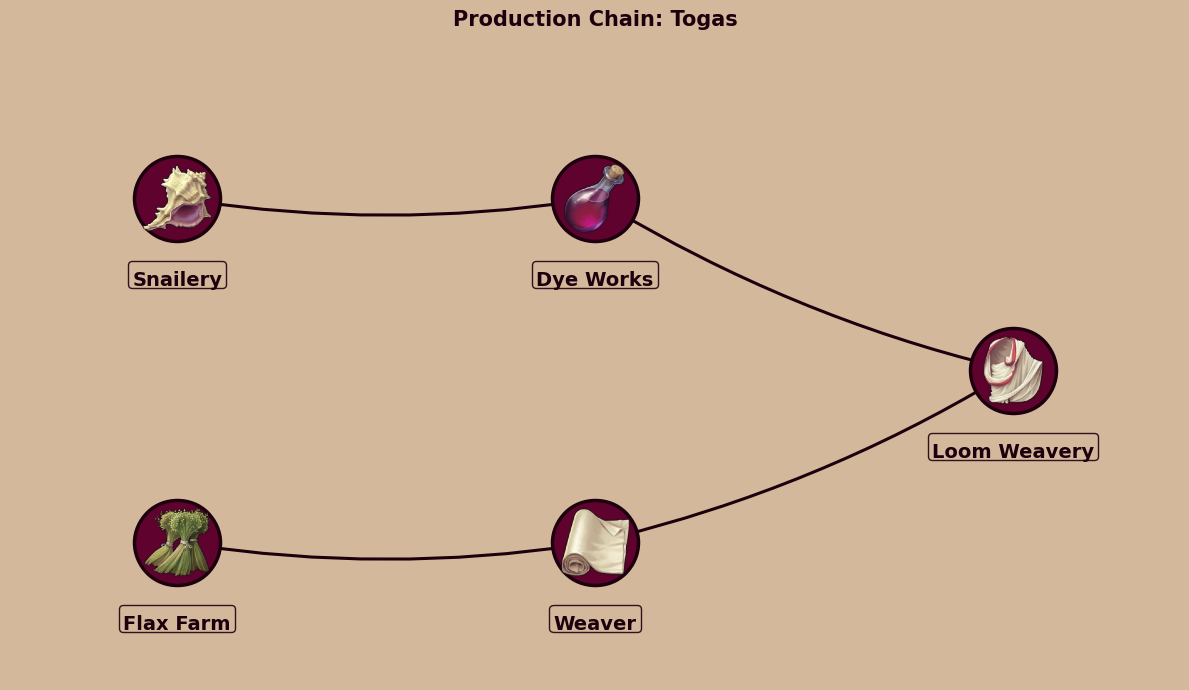

In [8]:
# Draw a specific chain (e.g., Production Chain Roman Togas - GUID: 3291)
extractor.draw_graph(3291)

  [OK] -> tmpxi4_dssn\node_145230.webp
  [OK] -> tmprk5l_byz\node_145102.webp
  [OK] -> tmpmdud9xnt\node_3081.webp
  [OK] -> tmps84ko2ue\node_8579.webp
  [OK] -> tmpt8m_7jcf\node_31755.webp
  [OK] -> tmpo518fkui\node_31753.webp


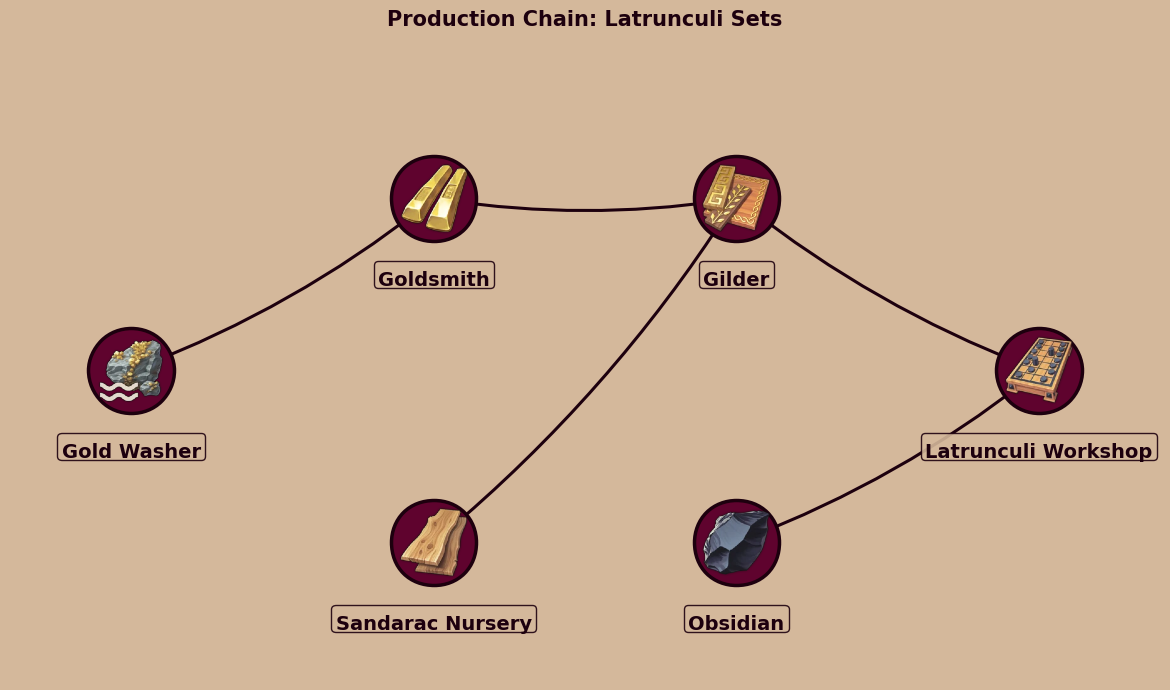

In [9]:
# Draw "Latrunculi Sets" chain (Production Chain Roman Boardgames - GUID: 145232)
extractor.draw_graph(145232)

  [OK] -> tmpaufvse64\node_4832.webp
  [OK] -> tmpa15sd0b4\node_5481.webp
  [OK] -> tmp0l8tglpb\node_3081.webp
  [OK] -> tmpf9gfotsg\node_2786.webp
  [OK] -> tmpy05gbals\node_8579.webp
  [OK] -> tmpl1ggdcf9\node_31755.webp
  [OK] -> tmpyetkex5s\node_31753.webp


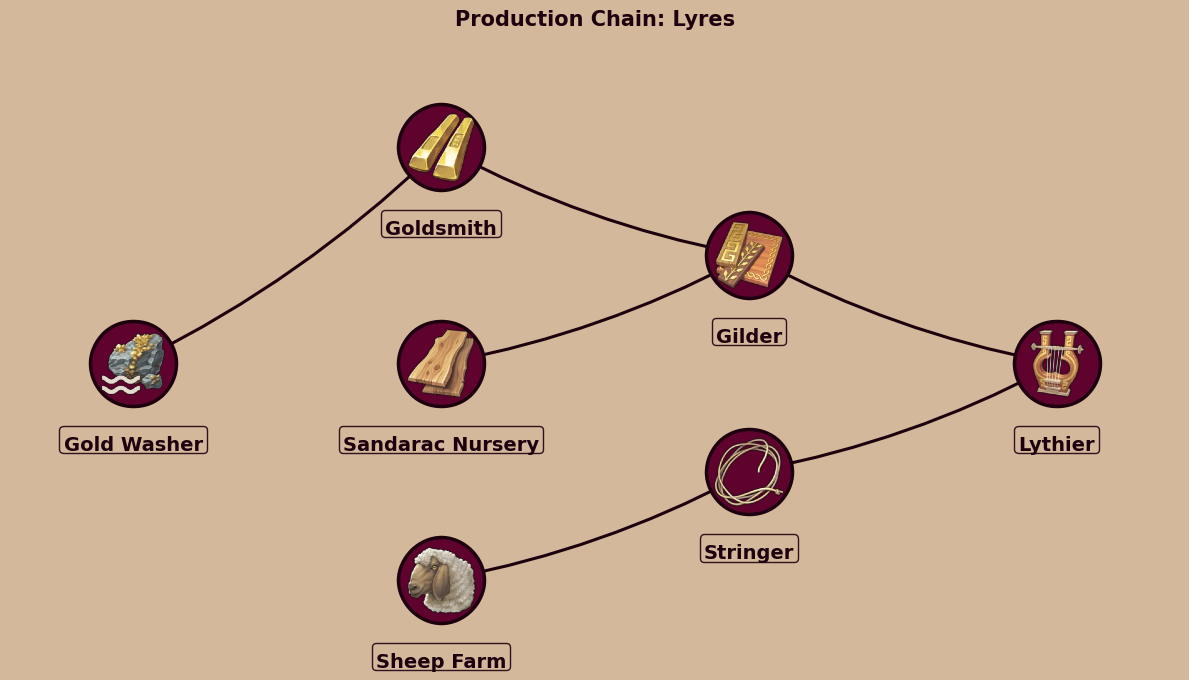

In [10]:
# Draw "Lyres" chain (Production Chain Roman Lyres - GUID: 8900)
extractor.draw_graph(8900)